###Enviornment
(1) Packages installation

In [1]:
%%capture
! pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain langchain_groq

##Tracing
Optionally, use LangSmith for tracing (shown at bottom) by setting:

In [2]:
from google.colab import userdata
import os

os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ["LANGCHAIN_PROJECT"] = "intro_to_RAG"

##Part 1: Overview
[RAG quickstart](https://python.langchain.com/docs/tutorials/rag)

###Agenda

- Loads and processes a web document

- Splits it into chunks

- Embeds and stores it in a vector database

- Retrieves relevant context for queries

- Generates responses concurrently (async) using Groq’s LLM

### Sync / Async Execution --> i chose (Async)
 - When you use .ainvoke() inside an async def function:

 - Each call (retriever / LLM API request) becomes non-blocking.

 - You can run multiple RAG queries at once using asyncio.gather().

 - Instead of waiting for one query to finish, your program can fire off many API requests in parallel and then collect the results when they’re done.

In [3]:
# Imports
import bs4
import asyncio
from langchain import hub
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_groq import ChatGroq
from langchain_community.embeddings import SentenceTransformerEmbeddings
from google.colab import userdata # Import userdata

# for snaps
from IPython.display import Image, display

In [5]:
#### ASYNC INDEXING + RETRIEVAL with Groq ####

async def main():
  # ---------------------------------
  # 1. Documents Loading
  # ---------------------------------
    loader = WebBaseLoader(
        web_paths=["https://lilianweng.github.io/posts/2023-06-23-agent/"],
        bs_kwargs=dict(
            parse_only=bs4.SoupStrainer(
                class_=("post-content", "post-title", "post-header")
            ) # BeautifulSoup to extract only desired HTML sections (post-content, post-title
        ),
    )
    docs = loader.load()

    # ------------------------------
    # 2. Text splitting
    # ------------------------------
    # Split into chunks

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000, chunk_overlap=200
    )
    splits = text_splitter.split_documents(docs)

    # --------------------------------------
    # 3. Embedding + Vector Database
    # --------------------------------------
    # Embed and store in vector DB
    # Instantiate your embedding function here

    embeddings = SentenceTransformerEmbeddings(model_name="all-mpnet-base-v2")
    vectorstore = Chroma.from_documents(
        documents=splits,
        embedding=embeddings # <- Replace None with your instantiated embedding function
    )
    # ------------------------------
    # 4. Retriever Creation
    # ------------------------------

    retriever = vectorstore.as_retriever()

    #### RETRIEVAL and GENERATION ####

    # ---------------------------------
    # 5. Prompt Template
    # ---------------------------------

    prompt = hub.pull("rlm/rag-prompt")

    # --------------------------------
    # 6. Groq LLM Initialization
    # --------------------------------
    llm = ChatGroq(
        groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
        model="meta-llama/llama-4-scout-17b-16e-instruct", # you can switch to other Groq-supported models
        temperature=0
    )

    # Post-processing helper
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # ----------------------------------
    # 7. RAG Chain Definition
    # ----------------------------------
    # Async RAG chain
    rag_chain = (
        {
            "context": retriever | format_docs,
            "question": RunnablePassthrough()# Just forward input as output(act as a placeholder for the question)
        }
        | prompt
        | llm
        | StrOutputParser()
    )

    # --------------------------------------
    # 8. Asynchronous Query Execution
    # --------------------------------------
    # Run query asynchronously
    # Run multiple queries in parallel

    responses = await asyncio.gather(
    rag_chain.ainvoke("What is Task Decomposition?"),
    rag_chain.ainvoke("Explain Task Planning."),
    rag_chain.ainvoke("What are memory mechanisms in agents?")
)

    # -------------------------
    # 9. Display Results
    # -------------------------
    for r in responses:
        print(r)

# Run the async function directly with await
await main()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Task Decomposition is a process of breaking down a complex task into smaller and simpler steps. This can be done through various methods, including prompting a large language model (LLM) with simple questions, using task-specific instructions, or incorporating human inputs. It enables the transformation of big tasks into multiple manageable tasks, shedding light on the model's thinking process.
Task planning refers to the process of breaking down a complex task into smaller, manageable steps. This can be achieved through various methods, including using large language models (LLMs) with prompting techniques, task-specific instructions, or human inputs. The goal of task planning is to enable an agent to plan ahead and execute a series of steps to achieve a complicated task.
Memory mechanisms in agents include the reflection mechanism, retrieval model, and memory stream. The reflection mechanism synthesizes memories into higher-level inferences to guide future behavior, while the retriev

###Part 2: Breaking down all the components of RAG:
#### 1. Indexing


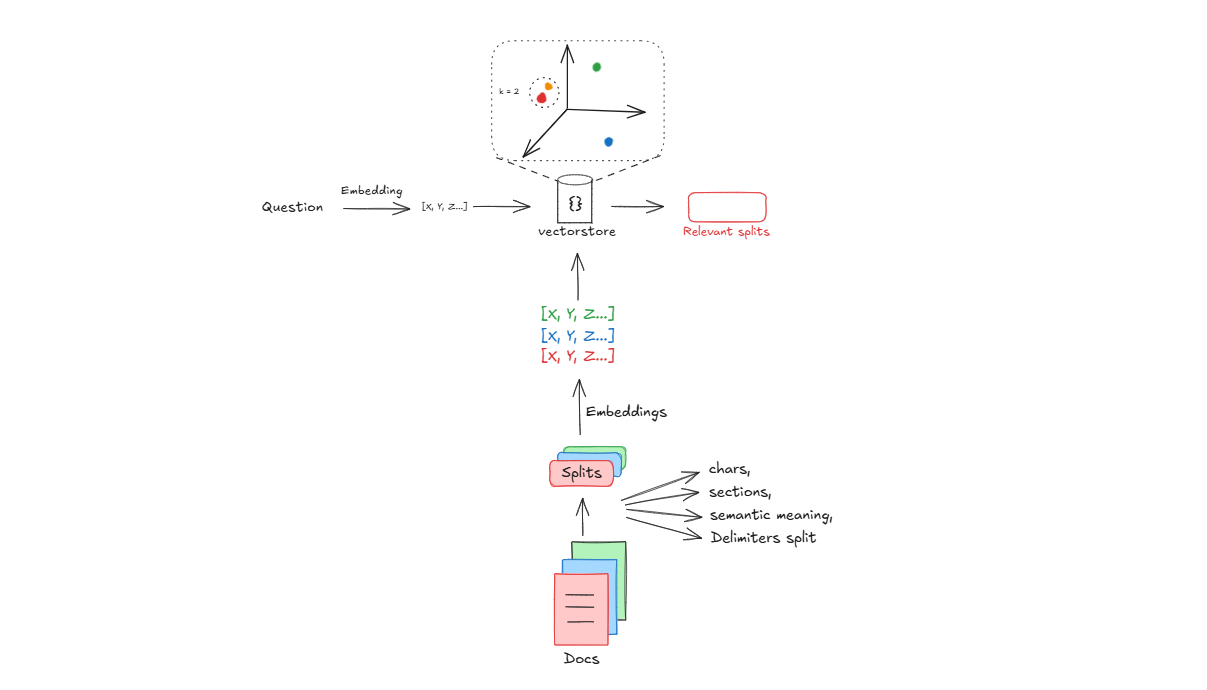

In [ ]:
display(Image(filename="/content/Screenshot 2025-08-30 234859.png"))

In [6]:
# Documents
question = "Do i like cats?"
document = "My favorite pet is a cat."

[learn how to count tokens](https://github.com/openai/openai-cookbook/blob/main/examples/How_to_count_tokens_with_tiktoken.ipynb) considering [~4 char / tokens ](https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them)

In [7]:
import tiktoken

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

num_tokens_from_string(question, "cl100k_base")

5

[Text embedding models](https://python.langchain.com/docs/integrations/text_embedding/openai/)

In [11]:
# Instantiate embedding model
embd = SentenceTransformerEmbeddings(model_name="all-mpnet-base-v2")

# Embed a query (single text)
query_result = embd.embed_query(question)

# Embed document(s) — expects a list of strings
document_result = embd.embed_documents([document])

# Print embedding dimension
print(f"Total dimensions of our embedding model: {len(query_result)}")


Total dimensions of our embedding model: 768


[Cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) is reccomended (1 indicates identical)

In [13]:
import numpy as np

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    return dot_product / (norm_vec1 * norm_vec2)

# Reshape document_result to be a 1D array
similarity = cosine_similarity(query_result, document_result[0])
print("Cosine Similarity:", similarity)

Cosine Similarity: 0.5810650635228448


[Doc Loaders](https://python.langchain.com/docs/integrations/document_loaders)

In [14]:
# Load blog
import bs4
from langchain_community.document_loaders import WebBaseLoader
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
blog_docs = loader.load()

[Splitter](https://python.langchain.com/docs/how_to/recursive_text_splitter/) <br>
- This text splitter is the recommended one for generic text. It is parameterized by a list of characters. It tries to split on them in order until the chunks are small enough. The default list is ["\n\n", "\n", " ", ""]. This has the effect of trying to keep all paragraphs (and then sentences, and then words) together as long as possible, as those would generically seem to be the strongest semantically related pieces of text.




In [15]:
# Split
from langchain.text_splitter import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=300,
    chunk_overlap=50)

# Make splits
splits = text_splitter.split_documents(blog_docs)
splits[0]

Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refin

[Vectorstores](https://python.langchain.com/docs/integrations/vectorstores)

In [17]:
embeddings = SentenceTransformerEmbeddings(model_name="all-mpnet-base-v2")
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings)

# Retriever
retriever = vectorstore.as_retriever()

#### 2. Retrieval

In [18]:
embeddings = SentenceTransformerEmbeddings(model_name="all-mpnet-base-v2")
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings)

# Retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

In [19]:
docs = retriever.get_relevant_documents("What is Task Decomposition?")

/tmp/ipython-input-4059233835.py:1: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  docs = retriever.get_relevant_documents("What is Task Decomposition?")


In [20]:
for i, d in enumerate(docs):
    print(f"\n--- Document {i+1} ---")
    print("Content:", d.page_content[:200], "...")   # print first 200 chars
    print("Metadata:", d.metadata)


--- Document 1 ---
Content: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outl ...
Metadata: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}

--- Document 2 ---
Content: Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a s ...
Metadata: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}


###3. Generation

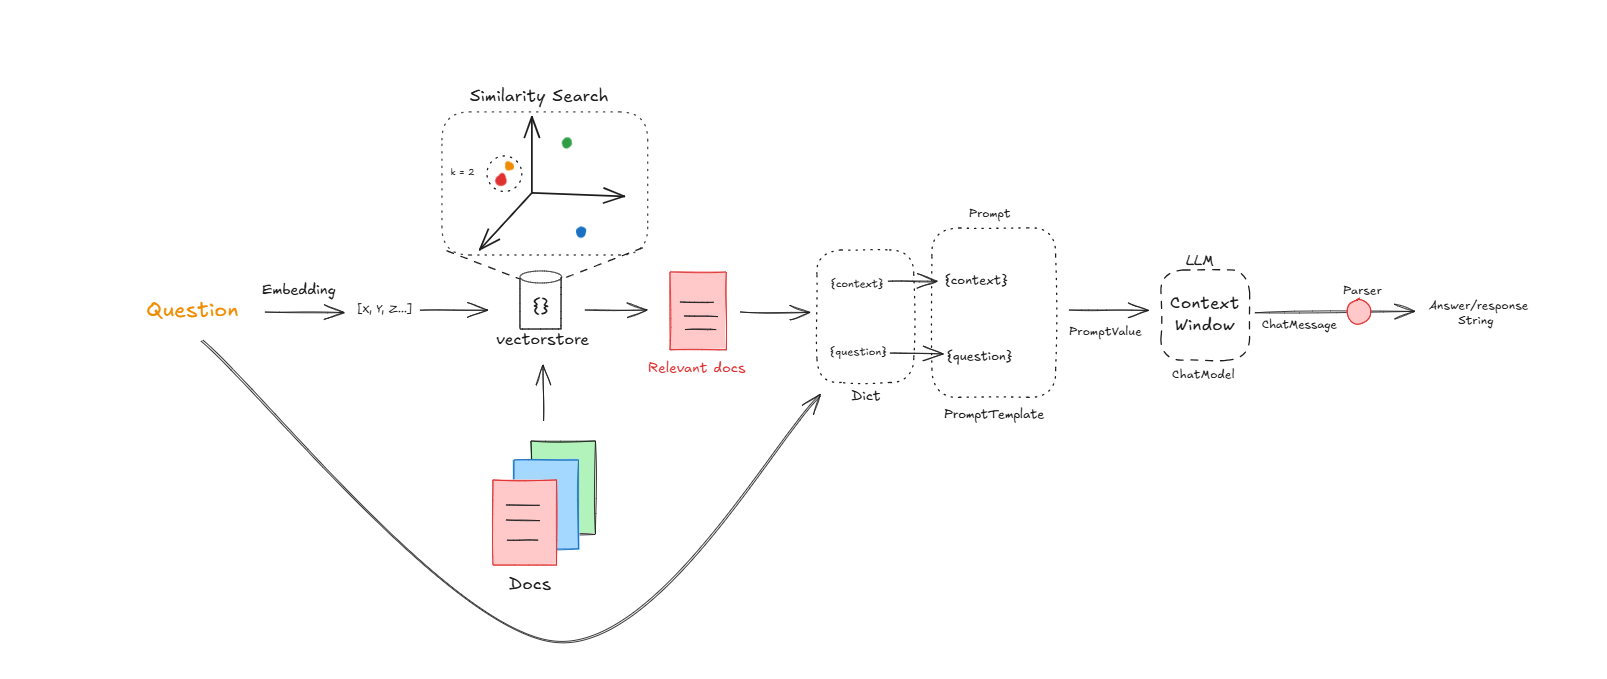

In [ ]:
display(Image(filename="/content/Screenshot 2025-08-31 002240.png"))

In [21]:
from langchain.prompts import ChatPromptTemplate
# Prompt
template = """Answer the question based on the following context:
{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based on the following context:\n{context}\n\nQuestion: {question}\n'), additional_kwargs={})])

In [22]:
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="meta-llama/llama-4-scout-17b-16e-instruct", # you can switch to other Groq-supported models
    temperature=0)

In [28]:
# Chain
chain = prompt | llm

In [29]:
# Run
chain.invoke({"context": docs, "question": "What is Task Decomposition?"})

AIMessage(content='Based on the provided context, Task Decomposition refers to the process of breaking down a complicated task into smaller and simpler steps. This can be achieved through various methods, including:\n\n1. Using Large Language Models (LLM) with simple prompting, such as "Steps for XYZ.\\\\n1." or "What are the subgoals for achieving XYZ?"\n2. Utilizing task-specific instructions, like "Write a story outline." for writing a novel\n3. Incorporating human inputs\n\nThe goal of task decomposition is to make complex tasks more manageable by identifying the individual steps or subgoals required to achieve the overall objective. This process can provide insight into the model\'s thinking process and facilitate more effective problem-solving. Techniques like Chain of Thought (CoT) and Tree of Thoughts (ToT) also rely on task decomposition to enhance model performance on complex tasks.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 171, 'prompt_t

In [30]:
from langchain import hub
prompt_hub_rag = hub.pull("rlm/rag-prompt")
prompt_hub_rag

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

[RAG Chains](https://python.langchain.com/docs/how_to/sequence)

In [31]:
rag_chain = (
    {
        "context": retriever,
        "question": RunnablePassthrough()
    }
    | prompt_hub_rag
    | llm
    | StrOutputParser()
)

rag_chain.invoke("What is Task Decomposition?")

"Task decomposition is a process of breaking down a complicated task into smaller and simpler steps. It can be done through various methods, including using large language models (LLM) with simple prompting, task-specific instructions, or human inputs. This technique helps transform big tasks into multiple manageable tasks and sheds light on the model's thinking process."

Langsmith trace:
https://smith.langchain.com/public/f988c560-a126-46eb-9d32-89a37cc65076/r